In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import seaborn as sns 
import matplotlib.pyplot as plt 
from keras import regularizers
from keras.layers import Dense,Flatten,Dropout
from keras.models import Sequential

In [5]:
mnist =tf.keras.datasets.mnist

In [6]:
mnist

<module 'keras.datasets.mnist' from 'e:\\Deep Learning\\venv\\lib\\site-packages\\keras\\datasets\\mnist\\__init__.py'>

In [7]:
(X_train_full,y_train_full),(X_test,y_test)=mnist.load_data()

In [9]:
X_train_full[0].shape

(28, 28)

In [10]:
X_valid,X_train=X_train_full[:5000]/255. ,X_train_full[5000:]/255.
y_valid,y_train=y_train_full[:5000],y_train_full[5000:]
X_test=X_test/255.

In [13]:
X_train_full.shape,X_train.shape,X_test.shape,y_train.shape,X_valid.shape

((60000, 28, 28), (55000, 28, 28), (10000, 28, 28), (55000,), (5000, 28, 28))

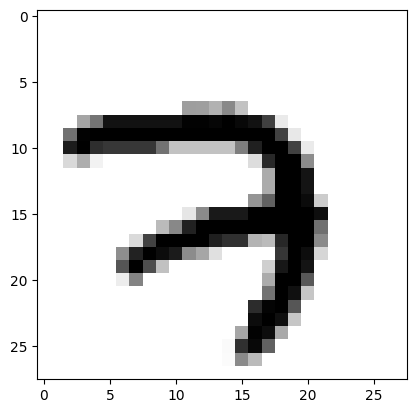

In [11]:
plt.imshow(X_train[0],cmap='binary')
plt.show()

<Axes: >

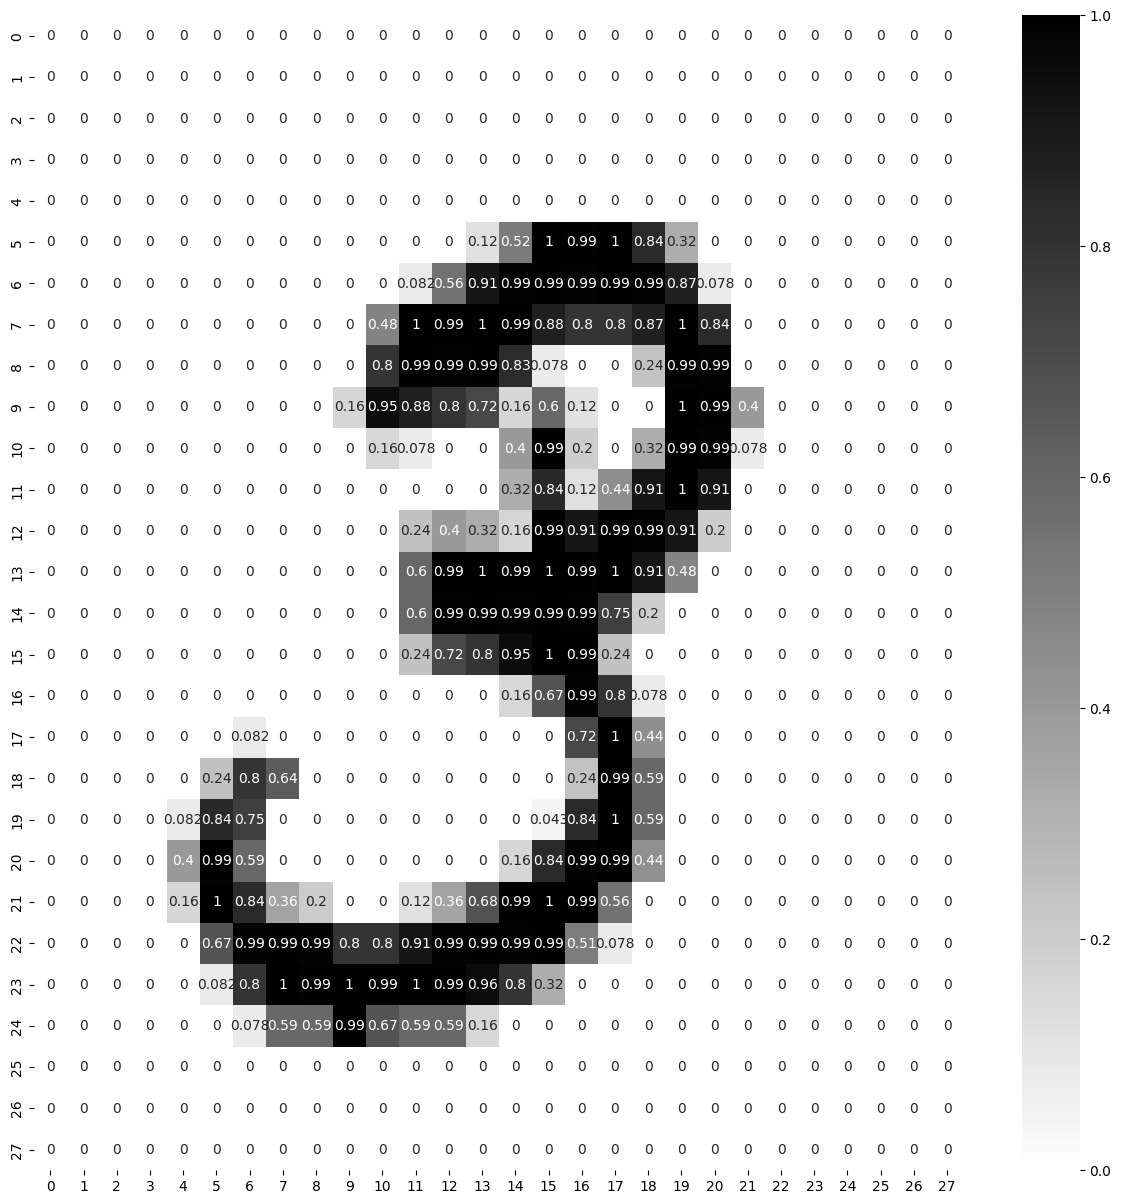

In [14]:
plt.figure(figsize=(15,15))
sns.heatmap(X_train[1],annot=True,cmap='binary')

In [22]:
LAYERS=[tf.keras.layers.Flatten(input_shape=[28,28],name='inputLayer'),
        tf.keras.layers.Dense(300,name='hiddenLayer1',activation='relu',kernel_regularizer=regularizers.L1L2(l1=1e-4,l2=1e-3)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(100,name='hiddenLayer2',activation='relu',kernel_regularizer=regularizers.L1(1e-5)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(10,name='outputLayer',activation='softmax')
]
model_clf=tf.keras.models.Sequential(LAYERS)

In [23]:
model_clf.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputLayer (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hiddenLayer1 (Dense)            │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 300)            │         1,200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hiddenLayer2 (Dense)            │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputLayer (Dense)             │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,210 (1.02 MB)

 Trainable params: 267,410 (1.02 MB)

 Non-trainable params: 800 (3.12 KB)

In [24]:
loss_fn='sparse_categorical_crossentropy'
opti='ADAM'
metrics=['accuracy']
model_clf.compile(loss=loss_fn,optimizer=opti,metrics=metrics)

In [27]:
epochs=7
validation_Set=(X_valid,y_valid)
history =model_clf.fit(X_train,y_train,epochs=epochs,validation_data=validation_Set,batch_size=32)

Epoch 1/7
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9184 - loss: 0.7658 - val_accuracy: 0.9622 - val_loss: 0.4456
Epoch 2/7
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9438 - loss: 0.4635 - val_accuracy: 0.9576 - val_loss: 0.3822
Epoch 3/7
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9475 - loss: 0.4116 - val_accuracy: 0.9632 - val_loss: 0.3462
Epoch 4/7
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9491 - loss: 0.3804 - val_accuracy: 0.9686 - val_loss: 0.3201
Epoch 5/7
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9509 - loss: 0.3660 - val_accuracy: 0.9698 - val_loss: 0.3068
Epoch 6/7
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9509 - loss: 0.3543 - val_accuracy: 0.9612 - val_loss: 0.3172
Epoch 7/7
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9525 - loss: 0.3430 - val_accuracy: 0.9670 - val_loss: 0.2971


In [30]:
df=pd.DataFrame(history.history)
df

,accuracy,loss,val_accuracy,val_loss
0,0.918400,0.765789,0.9622,0.445593
1,0.943836,0.463456,0.9576,0.382187
2,0.947545,0.411552,0.9632,0.346198
3,0.949109,0.380376,0.9686,0.320096
4,0.950909,0.365991,0.9698,0.306821
5,0.950855,0.354256,0.9612,0.317153
6,0.952527,0.342992,0.9670,0.297132


<Axes: >

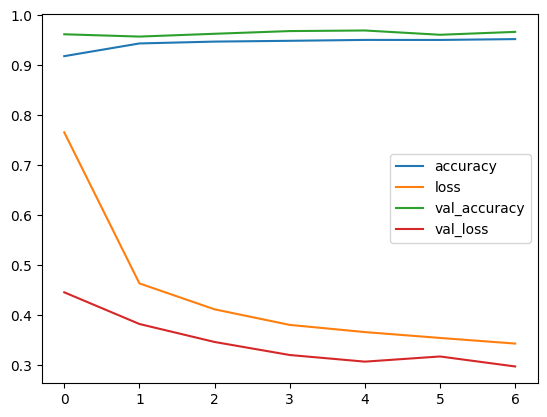

In [31]:
df.plot()

In [33]:
model_clf.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9634 - loss: 0.3017


[0.3016583025455475, 0.9634000062942505]

In [34]:
x_new=X_test[:3]
actual=y_test[:3]
actual

array([7, 2, 1], dtype=uint8)

<Axes: >

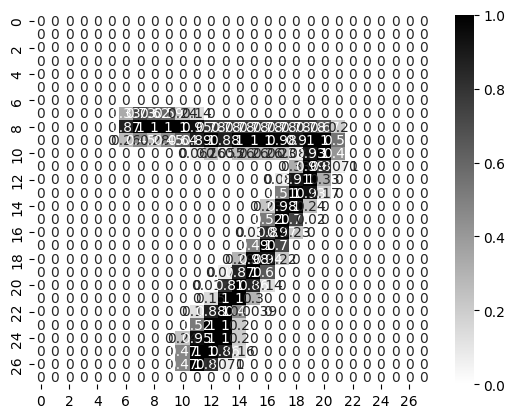

In [36]:
sns.heatmap(X_test[0],annot=True,cmap='binary')

In [42]:
y_prob=model_clf.predict(x_new)
y_prob.round(3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


array([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [43]:
y_prob

array([[6.8503941e-06, 1.5971542e-05, 4.6948053e-06, 1.2922029e-05,
        2.5502684e-06, 7.9125243e-07, 9.0319112e-08, 9.9994707e-01,
        1.3228679e-07, 9.0045869e-06],
       [2.7424610e-05, 2.3660892e-05, 9.9957913e-01, 3.3684936e-04,
        7.8350524e-08, 2.9138650e-06, 3.6837653e-06, 6.4414841e-08,
        2.6205207e-05, 1.7228755e-09],
       [5.6992241e-07, 9.9978262e-01, 1.6406675e-05, 3.8211274e-06,
        1.7422710e-05, 1.4448564e-05, 2.3288708e-06, 1.5901875e-04,
        3.2437713e-06, 2.8646022e-07]], dtype=float32)

In [44]:
y_pred=np.argmax(y_prob,axis=-1)

In [45]:
y_pred

array([7, 2, 1])

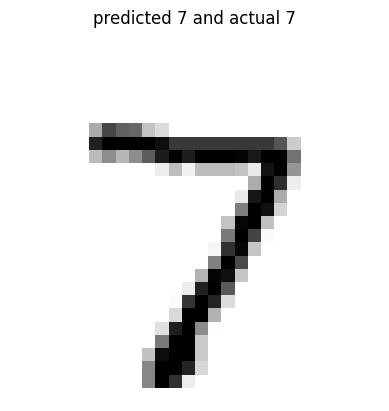

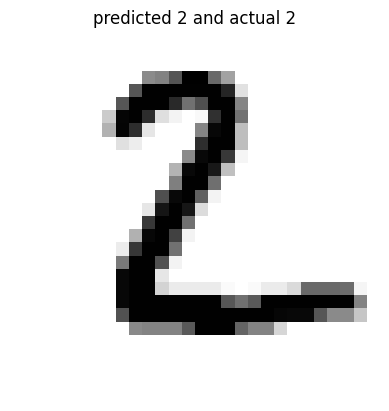

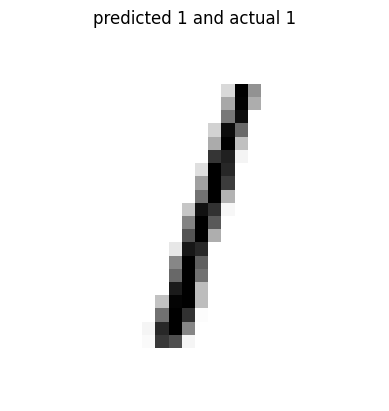

In [47]:
for data,pred,actual_data in zip(x_new,y_pred,actual):
    plt.imshow(data,cmap='binary')
    plt.title(f"predicted {pred} and actual {actual_data}")
    plt.axis('off')
    plt.show()
    print("="*40)